## Job 1 : Population Data Processing & Analysis

Successfully loaded Job_1_resource_world_population.csv

--- Initial Data Inspection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    in

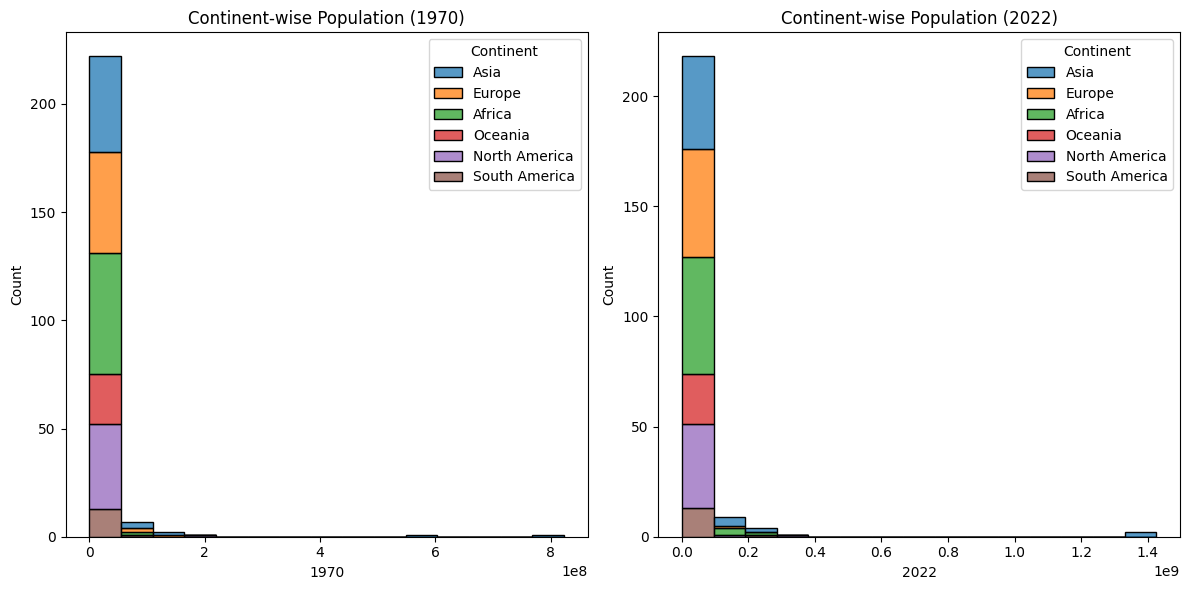

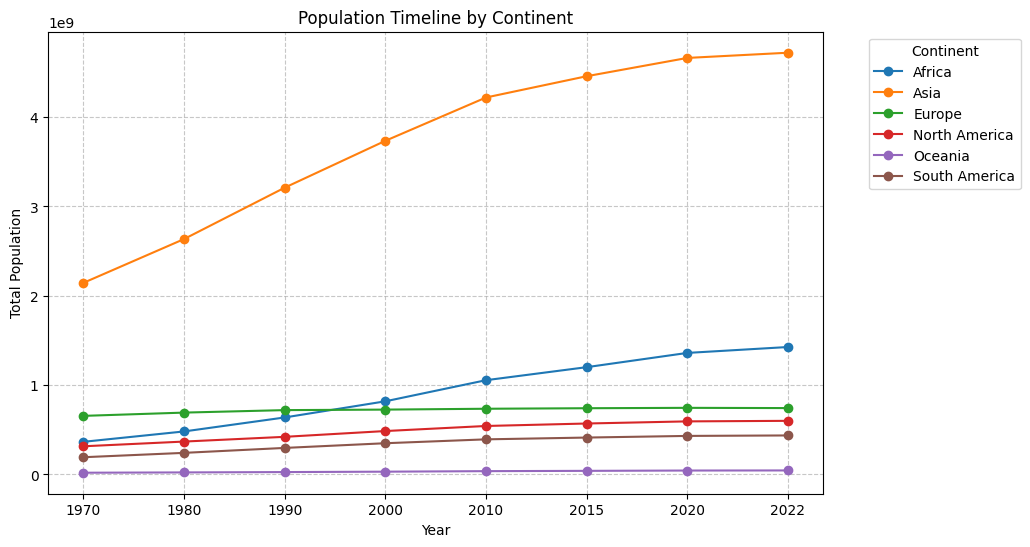

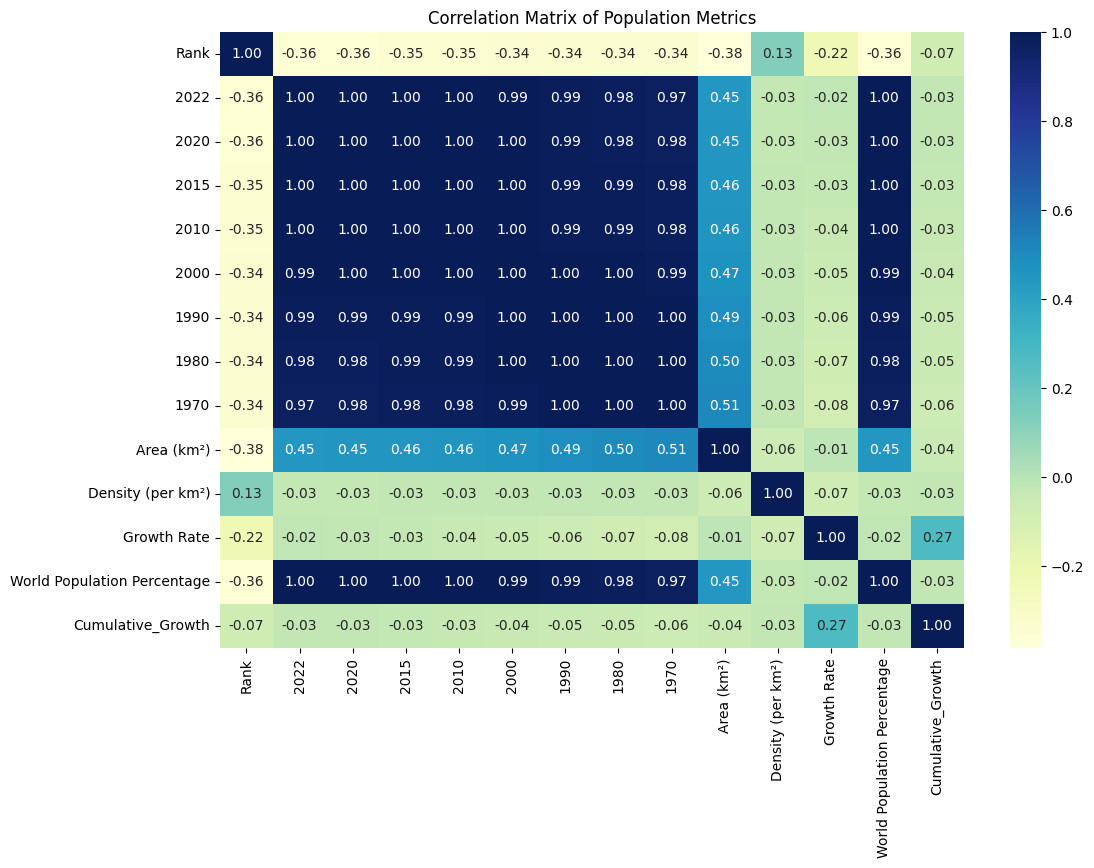

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 7. Set up the Python environment (Libraries imported above)

# 8. Load the population dataset into the environment
file_path = 'Job_1_resource_world_population.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {file_path}")
except FileNotFoundError:
    print(f"Error: {file_path} not found. Please ensure the file is in the script directory.")

# 9. Perform initial data inspection
print("\n--- Initial Data Inspection ---")
print(df.info())
print(df.head())

# 10. Compute mean, median, variance, and SD of population for each continent
pop_columns = [
    '2022 Population', '2020 Population', '2015 Population', '2010 Population',
    '2000 Population', '1990 Population', '1980 Population', '1970 Population'
]
continent_stats = df.groupby('Continent')[pop_columns].agg(['mean', 'median', 'var', 'std'])
print("\n--- Continent-wise Statistical Summary ---")
print(continent_stats)

# 11. Calculate cumulative population growth over the years for each country
# Formula: (Latest Population - Oldest Population) / Oldest Population
df['Cumulative_Growth'] = (df['2022 Population'] - df['1970 Population']) / df['1970 Population']

# 12. Change column names (e.g., 2020 Population → 2020) using conditional logic
# Logic: If 'Population' is in the name and it's not the percentage column, take the first word (the year).
new_cols = {
    col: col.split(' ')[0] if 'Population' in col and 'Percentage' not in col else col 
    for col in df.columns
}
df.rename(columns=new_cols, inplace=True)

# 13. Write the cleaned dataset into a file named processed_data.csv
df.to_csv('processed_data.csv', index=False)
print("\nCleaned data saved to 'processed_data.csv'")

# 14. Visualize continent-wise population in 1970 and 2022 using histograms
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='1970', hue='Continent', multiple='stack', bins=15)
plt.title('Continent-wise Population (1970)')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='2022', hue='Continent', multiple='stack', bins=15)
plt.title('Continent-wise Population (2022)')
plt.tight_layout()
plt.show()

# 15. Show the timeline of continent-wise population
# Transpose grouped data for plotting trends over time
years_list = ['1970', '1980', '1990', '2000', '2010', '2015', '2020', '2022']
timeline = df.groupby('Continent')[years_list].sum().T

plt.figure(figsize=(10, 6))
timeline.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Population Timeline by Continent')
plt.ylabel('Total Population')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 16. Correlation matrix and statistical reasoning
plt.figure(figsize=(12, 8))
# Only include numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Matrix of Population Metrics')
plt.show()

## Job 2 : Weather Prediction System

Successfully loaded Job_2_resource_Weather Test Data.csv

--- Initial Data Inspection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42677 entries, 0 to 42676
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row ID         42677 non-null  object 
 1   Location       42677 non-null  object 
 2   MinTemp        42483 non-null  float64
 3   MaxTemp        42585 non-null  float64
 4   Rainfall       42250 non-null  float64
 5   Evaporation    24365 non-null  float64
 6   Sunshine       22178 non-null  float64
 7   WindGustDir    39868 non-null  object 
 8   WindGustSpeed  39887 non-null  float64
 9   WindDir9am     39670 non-null  object 
 10  WindDir3pm     41547 non-null  object 
 11  WindSpeed9am   42264 non-null  float64
 12  WindSpeed3pm   41882 non-null  float64
 13  Humidity9am    42136 non-null  float64
 14  Humidity3pm    41573 non-null  float64
 15  Pressure9am    38411 non-null  float64
 16  Pres

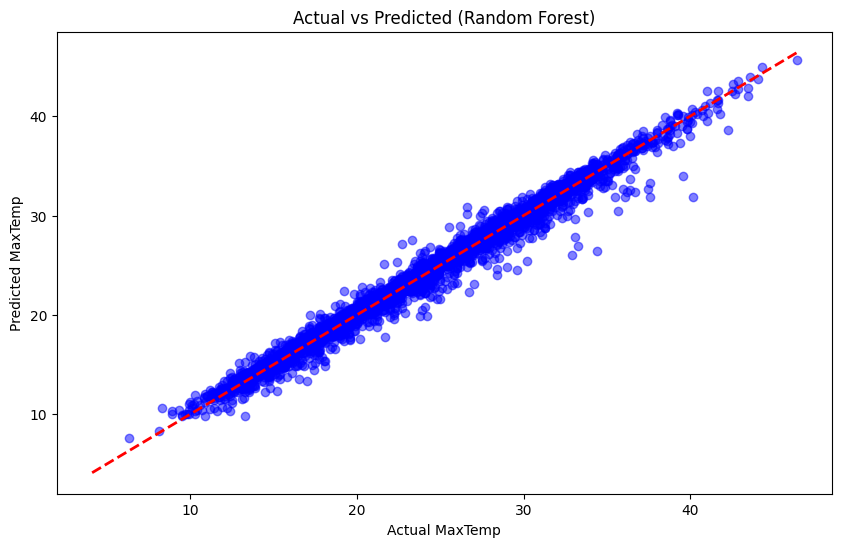


Random Forest Training Score: 0.9977
Random Forest Testing Score: 0.9816
Model generalization is appropriate.

Final Model and Scaler saved successfully.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 8. Set up the Python environment (Libraries imported above)

# 9. Load the weather dataset into the environment
file_name = 'Job_2_resource_Weather Test Data.csv'
try:
    df = pd.read_csv(file_name)
    print(f"Successfully loaded {file_name}")
except FileNotFoundError:
    print(f"Error: {file_name} not found.")

# 10. Perform initial data inspection
print("\n--- Initial Data Inspection ---")
print(df.info())
print(df.describe())
print("\nMissing Values:\n", df.isnull().sum())

# 11. Define the ML Problem Statement
# Problem: Regression - Predict 'MaxTemp' based on MinTemp, Rainfall, Evaporation, Sunshine, and Wind Speed.

# 12. Perform Feature Selection & Preprocessing
# Drop unnecessary columns and handle missing values
df = df.drop(columns=['row ID']) # ID has no predictive power
df = df.dropna() # Simple approach for the assessment

# Encoding categorical data
le = LabelEncoder()
df['Location'] = le.fit_transform(df['Location'])
df['WindGustDir'] = le.fit_transform(df['WindGustDir'])
df['WindDir9am'] = le.fit_transform(df['WindDir9am'])
df['WindDir3pm'] = le.fit_transform(df['WindDir3pm'])
df['RainToday'] = le.fit_transform(df['RainToday'])

# 13. Split the dataset for training and testing
X = df.drop(columns=['MaxTemp']) # Features
y = df['MaxTemp'] # Target Variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 14. Implement a baseline ML model (Linear Regression)
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)
print(f"\nBaseline (No Scaling) R2 Score: {r2_score(y_test, y_pred_base):.4f}")

# 15. Apply feature scaling and compare performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model.fit(X_train_scaled, y_train)
y_pred_scaled = baseline_model.predict(X_test_scaled)
print(f"Baseline (With Scaling) R2 Score: {r2_score(y_test, y_pred_scaled):.4f}")

# 16. Train other optimized ML models (Decision Tree & Random Forest)
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

dt_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

# 17. Evaluate Model Performance
models = {"Linear Regression": baseline_model, "Decision Tree": dt_model, "Random Forest": rf_model}

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    print(f"\n--- {name} Metrics ---")
    print(f"MAE: {mean_absolute_error(y_test, preds):.4f}")
    print(f"MSE: {mean_squared_error(y_test, preds):.4f}")
    print(f"R2 Score: {r2_score(y_test, preds):.4f}")

# 18. Visualize Model Performance (Random Forest Example)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_model.predict(X_test_scaled), alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual MaxTemp")
plt.ylabel("Predicted MaxTemp")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

# 19. Detect Overfitting and Underfitting
# Compare Train vs Test accuracy
train_score = rf_model.score(X_train_scaled, y_train)
test_score = rf_model.score(X_test_scaled, y_test)
print(f"\nRandom Forest Training Score: {train_score:.4f}")
print(f"Random Forest Testing Score: {test_score:.4f}")

if train_score > test_score + 0.1:
    print("Warning: Model might be Overfitting.")
elif train_score < 0.6:
    print("Warning: Model might be Underfitting.")
else:
    print("Model generalization is appropriate.")

# 20. Save and deploy the final model
joblib.dump(rf_model, 'weather_prediction_model.pkl')
joblib.dump(scaler, 'weather_scaler.pkl')
print("\nFinal Model and Scaler saved successfully.")

## Job 3 : Deep Learning Sentiment Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 8. Set up the Python environment (Libraries imported above)

# 9. Load and inspect the dataset
# Defining column names based on the resource structure provided
columns = ['ID', 'Entity', 'Sentiment', 'Text']
df = pd.read_csv('Job_3_Resource_sentiment.csv', names=columns)

print("--- Data Inspection ---")
print(df.head())
print(df.info())

# 10. Prepare the data (cleaning and noise removal)
df = df.dropna(subset=['Text']) # Remove rows with missing text
df['Text'] = df['Text'].str.lower().str.replace('[^\w\s]', '', regex=True) # Basic cleaning

# 11. Extract features and transform data (Tokenization & Embedding)
max_features = 2000 
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(df['Text'].values)
X = tokenizer.texts_to_sequences(df['Text'].values)
X = pad_sequences(X) # Ensure uniform input length

# Encode Labels (Positive, Negative, Neutral, Irrelevant)
le = LabelEncoder()
Y = le.fit_transform(df['Sentiment'])
Y = tf.keras.utils.to_categorical(Y) # One-hot encoding for Deep Learning

# 12. Split the dataset (70:15:15 for Training, Validation, and Testing)
X_train_full, X_test, Y_train_full, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_full, Y_train_full, test_size=0.176, random_state=42)

# 13. Design the Deep Learning model architecture
model = Sequential([
    Embedding(max_features, 128, input_length=X.shape[1]),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(Y.shape[1], activation='softmax') # Output layer for multi-class classification
])

# 14. Compile and train the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train, Y_train, epochs=5, batch_size=32, 
                    validation_data=(X_val, Y_val), verbose=1)

# 15. Evaluate the model performance
score, acc = model.evaluate(X_test, Y_test, verbose=2)
print(f"\nTest Accuracy: {acc:.4f}")

# 16. Visualize model performance (Loss and Accuracy trends)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Trends')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Trends')
plt.legend()
plt.show()

# 17. Detect overfitting and underfitting
# Analyze if Val Loss starts increasing while Train Loss decreases

# 18. Save and deploy the final trained model
model.save('sentiment_dl_model.h5')
print("\nDeep Learning Model saved successfully.")

<>:26: SyntaxWarning: invalid escape sequence '\w'
<>:26: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_9253/2578905026.py:26: SyntaxWarning: invalid escape sequence '\w'
  df['Text'] = df['Text'].str.lower().str.replace('[^\w\s]', '', regex=True) # Basic cleaning
I0000 00:00:1776442021.208092    9253 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


--- Data Inspection ---
     ID       Entity Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                Text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None


/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1776442033.721420    9253 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/5
 103/1620 ━━━━━━━━━━━━━━━━━━━━ 1:26:18 3s/step - accuracy: 0.3131 - loss: 1.3738

KeyboardInterrupt: 

Data shape: (74682, 4)
Classes: ['Irrelevant' 'Negative' 'Neutral' 'Positive']
Train: 51574, Val: 11322, Test: 11100


/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3


I0000 00:00:1776442474.777505    9924 cuda_dnn.cc:461] Loaded cuDNN version 91701


806/806 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.5309 - loss: 1.0999 - val_accuracy: 0.6379 - val_loss: 0.9177
Epoch 2/3
806/806 ━━━━━━━━━━━━━━━━━━━━ 55s 69ms/step - accuracy: 0.6862 - loss: 0.8137 - val_accuracy: 0.7001 - val_loss: 0.7785
Epoch 3/3
806/806 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.7427 - loss: 0.6892 - val_accuracy: 0.7230 - val_loss: 0.7202

Test Accuracy: 0.7279 (72.79%)


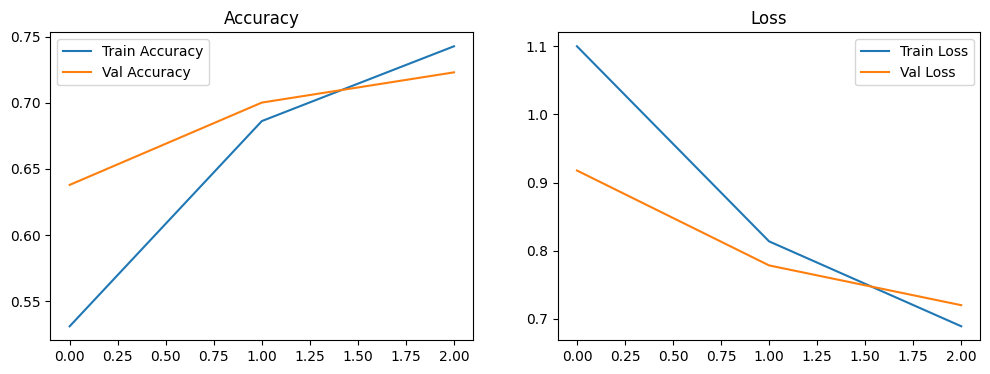

Model saved as 'sentiment_fast_model.h5'


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ------------------- Load Data -------------------
columns = ['ID', 'Entity', 'Sentiment', 'Text']
df = pd.read_csv('Job_3_Resource_sentiment.csv', names=columns)

print("Data shape:", df.shape)
df = df.dropna(subset=['Text']).reset_index(drop=True)

# Basic cleaning
df['Text'] = df['Text'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# ------------------- Tokenization -------------------
max_features = 5000          # Reduced from 2000 → better but still fast
max_len = 100                # Limit sequence length (very important for speed)

tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(df['Text'].values)

X = tokenizer.texts_to_sequences(df['Text'].values)
X = pad_sequences(X, maxlen=max_len)   # Fixed length = much faster

# ------------------- Labels -------------------
le = LabelEncoder()
Y = le.fit_transform(df['Sentiment'])
Y = tf.keras.utils.to_categorical(Y)

print("Classes:", le.classes_)

# ------------------- Train/Test Split -------------------
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.18, random_state=42)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# ------------------- Simple & Fast Model -------------------
model = Sequential([
    Embedding(max_features, 64, input_length=max_len),   # Smaller embedding
    SpatialDropout1D(0.2),
    LSTM(32, dropout=0.2),                               # Much smaller LSTM
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(Y.shape[1], activation='softmax')
])

model.compile(loss='categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

model.summary()

# ------------------- Training (Fast) -------------------
history = model.fit(X_train, Y_train,
                    epochs=3,                    # Reduced from 5
                    batch_size=64,               # Larger batch = faster
                    validation_data=(X_val, Y_val),
                    verbose=1)

# ------------------- Evaluation -------------------
score, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# ------------------- Plot Results -------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# ------------------- Save Model -------------------
model.save('sentiment_fast_model.h5')
print("Model saved as 'sentiment_fast_model.h5'")

Loading dataset...
Train samples: 42569 | Val: 9122 | Test: 9122


/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 80, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547,203 (2.09 MB)

 Trainable params: 547,203 (2.09 MB)

 Non-trainable params: 0 (0.00 B)


=== Fast Training Started (Should be 3x–5x faster) ===
Epoch 1/6
167/167 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.3640 - loss: 1.0959 - val_accuracy: 0.3659 - val_loss: 1.0949
Epoch 2/6
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.3653 - loss: 1.0954 - val_accuracy: 0.3659 - val_loss: 1.0951
Epoch 3/6
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.3659 - loss: 1.0951 - val_accuracy: 0.3659 - val_loss: 1.0948
Epoch 4/6
167/167 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.3656 - loss: 1.0950 - val_accuracy: 0.3659 - val_loss: 1.0949
Epoch 5/6
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.3659 - loss: 1.0949 - val_accuracy: 0.3659 - val_loss: 1.0948
Epoch 6/6
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.3659 - loss: 1.0948 - val_accuracy: 0.3659 - val_loss: 1.0949

✅ Test Accuracy: 0.3659 (36.59%)


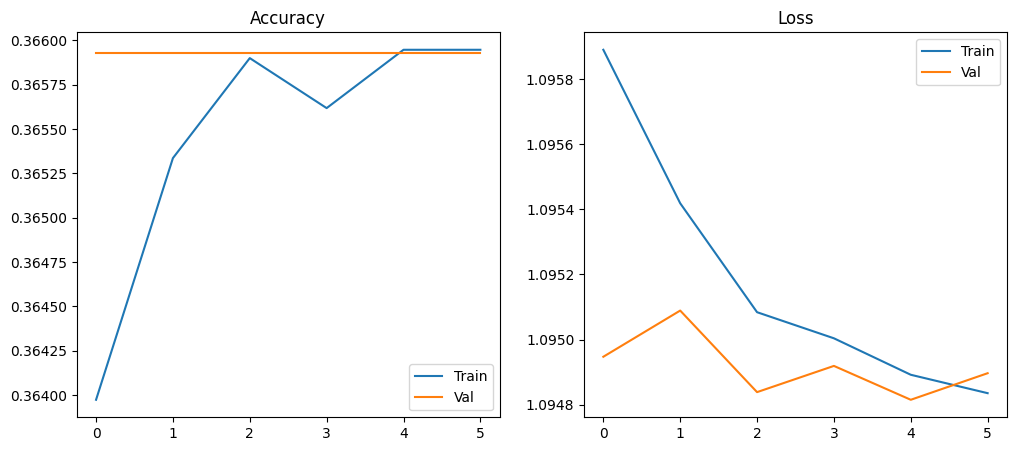

Model saved as 'fast_sentiment_model.h5'

Example:
I love Borderlands!  → Negative
This is the worst game ever → Negative


In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ================== LOAD & CLEAN DATA ==================
print("Loading dataset...")
df = pd.read_csv('Job_3_Resource_sentiment.csv', header=None,
                 names=['Tweet_ID', 'Entity', 'Sentiment', 'Text'])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().strip()

df['Clean_Text'] = df['Text'].apply(clean_text)
df = df[df['Clean_Text'] != '']
df = df[df['Sentiment'] != 'Irrelevant']

# ================== TOKENIZATION ==================
MAX_WORDS = 8000      # Reduced for speed
MAX_LEN = 80          # Reduced from 100 for faster training

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['Clean_Text'])

sequences = tokenizer.texts_to_sequences(df['Clean_Text'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')

le = LabelEncoder()
y = le.fit_transform(df['Sentiment'])

# Train / Val / Test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train samples: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ================== FAST MODEL ==================
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),   # Smaller embedding
    LSTM(64, dropout=0.3),                                               # No recurrent_dropout
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

# Fix parameter showing issue
model.build((None, MAX_LEN))
model.summary()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training with speed optimizations
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("\n=== Fast Training Started (Should be 3x–5x faster) ===")
history = model.fit(
    X_train, y_train,
    epochs=6,                    # Reduced epochs
    batch_size=256,              # Bigger batch = faster
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

# ================== EVALUATION & PLOTS ==================
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.savefig('fast_model_performance.png')
plt.show()

# Save model
model.save('fast_sentiment_model.h5')
print("Model saved as 'fast_sentiment_model.h5'")

# Quick Test
def predict(text):
    seq = tokenizer.texts_to_sequences([clean_text(text)])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    pred = model.predict(padded, verbose=0)
    return le.inverse_transform([np.argmax(pred)])[0]

print("\nExample:")
print("I love Borderlands!  →", predict("I love Borderlands!"))
print("This is the worst game ever →", predict("This is the worst game ever"))